# Assignment: Feature selection for classification of sweeteners/bitterants compounds

## Authors: Dario Piga, Manas Mejari, Gabriele Maroni

### Aim of the exercise session 

### Student name(s): Manuel Cattoni

In this exercise session, you will implement the algorithm (shown in the lesson) for feature selection based on hierarchical clustering. The algorithm will be applied for binary classification of the taste of food compounds (sweet or bitter) starting from numerical bio-chemical features describing each compounds.

## Instructions

Write your name (or names if you are working in a group) in the cell above

Write your solution in the cell below the exercise. Some cell have been already partially completed to facilitate your work. If it more conveninent for you, feel free to rewrite the entire cell/solution instead of using the pre-filled cell.


## Suggestions

Whenever possible, print the final results to check correctness of the solution. For debugging and understanding, it is sometimes convenient also to print intermediate results.

Note: We do not care about your codes!! We only care about the final results!


## Delivery

The jupyter notebook should be executed from the beginning, running the notebook as follows: `Kernel -> Restart & Run All`. Check that the printed solutions are the ones you are expecting. 

We will run your notebook. If it breaks, we will evaluate your exercise only up to the break. 

Submission deadline: 19th of May, 2025

## Exercise 1: dataset analysis and hierarchical clustering

In [1]:
# !pip install utils

In [2]:
# !pip install config

In [3]:
# Let us import some useful package (if needed, install the required packages)

import pickle
import itertools
import numpy as np
import pandas as pd



from scipy.cluster import hierarchy
from scipy.stats import spearmanr, pearsonr, ks_2samp

import sys
from utils import *
from config import *
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore')


%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import matplotlib as mlp
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
import random


mlp.rcParams['lines.linewidth'] = 2
mlp.rcParams['axes.grid'] = False
mlp.rcParams['grid.linestyle'] = '--'
mlp.rcParams['xtick.labelsize'] = 12
mlp.rcParams['ytick.labelsize'] = 12
mlp.rcParams['axes.labelsize'] = 14
mlp.rcParams['legend.fontsize'] = 12
#mlp.rcParams['axes.xmargin'] = 0.01
mlp.rcParams['font.size'] = 12
mlp.rcParams['figure.figsize'] = (5,5)


mlp.rcParams['font.family'] = 'serif'
mlp.rcParams['mathtext.fontset'] = 'dejavuserif'

Let us load the dataset, saved in the file *data* in the csv format. Each row of the dataframe represents a sample (molecule in our exercise) and each column represents a feature of the molecule. The last column is actually not a feature, but it represents the target output, namely taste of the molecule: sweet or bitter.

## IMPORTANT
The dataset can be downloaded from the link provided on iCorsi. To load the dataset using the cell above, save the file as *data.csv* in the same folder of your jupyter notebook.

In [4]:
# Load of the dataset
df = pd.read_csv('data.csv')
df

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,piPC4,piPC5,piPC6,piPC7,piPC8,piPC9,qed,rotors,sbonds,Taste
0,20.833333,6.045000,3.333333,6.777778,160.744081,81.948749,1.437948,6.115508,4.715278,7.613757,...,4.691348,4.976734,5.225747,5.442418,5.616771,5.726848,0.616435,0,16,Bitter
1,25.500000,6.740500,3.300000,9.100000,163.948014,100.746973,1.331653,6.753956,6.877778,8.260193,...,5.333926,5.786514,5.818227,5.862388,6.033985,6.248526,0.087270,11,33,Bitter
2,26.392157,6.818235,3.411765,9.882353,163.368509,104.373563,1.356914,6.830657,6.952614,8.325356,...,5.357765,5.865405,6.202282,6.430828,6.851350,7.056000,0.435162,5,18,Bitter
3,32.942529,7.414828,4.080460,13.850575,159.671541,130.985268,1.521055,7.415032,10.383780,8.831140,...,6.855672,7.393801,7.598023,7.754133,7.867381,8.302165,0.019798,31,62,Bitter
4,25.161290,6.677742,3.741935,9.451613,163.450461,99.389880,1.349502,6.697534,7.057236,8.200286,...,5.267858,5.707110,6.070738,6.371612,6.656727,6.945051,0.346678,4,33,Bitter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2190,26.900000,6.736000,3.600000,10.150000,160.308637,106.513077,1.475688,6.770442,7.119444,8.228655,...,5.254888,5.755347,5.900753,6.064875,6.243135,6.517440,0.501217,3,13,Bitter
2191,26.772727,6.764091,3.545455,10.227273,161.236964,105.972439,1.439747,6.791677,6.859217,8.260804,...,5.355406,5.868590,6.056784,6.224373,6.389506,6.637135,0.608327,4,15,Bitter
2192,25.219512,6.474510,3.243902,9.268293,160.107195,99.757642,1.516699,6.530112,5.980352,7.973253,...,5.110481,5.595640,5.671604,5.859361,5.978253,6.195744,0.796628,7,10,Bitter
2193,26.294118,6.510144,3.382353,9.529412,158.402482,104.161848,1.593682,6.574588,7.232843,7.988141,...,4.990433,5.460117,5.439437,5.620288,5.710220,6.026922,0.752904,5,7,Bitter


Since there are many NaN in the database, let us now replace NaN by a ficticious value: -99999

In [5]:
df.fillna(-99999, inplace=True)

df.shape

(2195, 1403)

### Exercise 1.1: Analyse your dataset.

- How many samples does it contain? How many sweet molecules? How many bitter molecules?
- How many features does it contain?
- (optional) Pick randomly 10 features, and for each selected features plot 2 histograms: 1 histogram of the feature for bitter molecules, another one for sweet molecules. 

In [6]:
# TO BE COMPLETED

# Hint: you can have a list of the name of the features through the command:

#features = df.drop(columns = ['Taste']).columns.to_list()

print(f"Number of samples: {df.shape[0]}")
print(f"Number of sweet molecules: {df[df['Taste'] == 'Sweet'].shape[0]}")
print(f"Number of bitter molecules: {df[df['Taste'] == 'Bitter'].shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")


# feature_columns = [col for col in df.columns if col != 'Taste']

# selected_features = random.sample(feature_columns, 10)

# fig, axs = plt.subplots(5, 2, figsize=(12, 18))
# axs = axs.flatten()

# for i, feature in enumerate(selected_features):
#     sns.histplot(df[df['Taste'] == 'Bitter'][feature], color='red', label='Bitter',
#                  stat="density", ax=axs[i], alpha=0.4)
#     sns.histplot(df[df['Taste'] == 'Sweet'][feature], color='blue', label='Sweet',
#                  stat="density", ax=axs[i], alpha=0.4)
#     axs[i].set_title(f'Feature: {feature}')
#     axs[i].legend()

# plt.tight_layout()
# plt.show()


Number of samples: 2195
Number of sweet molecules: 1043
Number of bitter molecules: 1152
Number of features: 1402


### Exercise 1.2: computing the correlation matrix 
In the dataframe, separate features from target and compute the correlation index among all the features. You should obtain a 1402x1402 correlation matrix with values between -1 and 1.

In [7]:
# TO BE COMPLETED

df_features = df.drop(columns=['Taste']) # Here extract the part of the dataframe containing all and only the features

# This line computes for you the correlation matrix. 
corr_df = df_features.corr(method='spearman').abs()
corr_df

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,piPC3,piPC4,piPC5,piPC6,piPC7,piPC8,piPC9,qed,rotors,sbonds
AATS0Z,1.000000,0.785052,0.640963,0.823312,0.255206,0.999895,0.591283,0.823842,0.601449,0.784915,...,0.367091,0.383803,0.383823,0.366375,0.340709,0.312727,0.297173,0.031782,0.220167,0.131032
AATS0are,0.785052,1.000000,0.597642,0.937586,0.073852,0.781832,0.143814,0.990610,0.875124,0.989956,...,0.337719,0.328353,0.316521,0.311470,0.290744,0.264155,0.252551,0.154734,0.058333,0.068753
AATS0d,0.640963,0.597642,1.000000,0.729905,0.488508,0.641990,0.580543,0.615818,0.427862,0.558076,...,0.844932,0.859330,0.852994,0.856738,0.830120,0.794976,0.770742,0.127965,0.248809,0.207923
AATS0dv,0.823312,0.937586,0.729905,1.000000,0.203197,0.821618,0.379961,0.940593,0.786341,0.903335,...,0.462348,0.473461,0.476349,0.462696,0.438708,0.402219,0.382604,0.006698,0.177189,0.057168
AATS0i,0.255206,0.073852,0.488508,0.203197,1.000000,0.258487,0.804594,0.021549,0.177078,0.105168,...,0.475887,0.522656,0.557703,0.536527,0.525001,0.496755,0.480553,0.366643,0.353581,0.266659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
piPC8,0.312727,0.264155,0.794976,0.402219,0.496755,0.314933,0.442403,0.278276,0.121127,0.226325,...,0.952714,0.955123,0.956194,0.964799,0.983102,1.000000,0.978890,0.078554,0.102229,0.413448
piPC9,0.297173,0.252551,0.770742,0.382604,0.480553,0.299353,0.416778,0.266561,0.115802,0.218128,...,0.935242,0.931722,0.931087,0.938905,0.958224,0.978890,1.000000,0.059058,0.128131,0.435267
qed,0.031782,0.154734,0.127965,0.006698,0.366643,0.034742,0.394671,0.136571,0.188564,0.185649,...,0.017441,0.075292,0.112640,0.087999,0.086029,0.078554,0.059058,1.000000,0.355150,0.398951
rotors,0.220167,0.058333,0.248809,0.177189,0.353581,0.220701,0.408488,0.085238,0.005081,0.040760,...,0.105348,0.044621,0.024231,0.019273,0.060075,0.102229,0.128131,0.355150,1.000000,0.565007


### Exercise 1.3 

Analyse your correlation matrix. Give answers to the following questions.

Consider feature number 0 (named AATS0Z):
- Is it "strongly" correlated with feature number 1 (AATS0are)? YES/NO? 
- Is it "strongly"  correlated with feature number 4 (AATS0i)? YES/NO? Is it more correlated to feature 0 than to feature number 1?

Write your answers below:
 

1. The feature 0 YES, is strongly correlated with feature 1, because it has a correlation = 0.785, which is high, others are better, but is owever a really good correlation
2. The feature 0 NO, is not strongly correlated with feature 4, beacuse the correlation is 0.255, that is bad, so the feature 1 is more correlated with feature 0

### Exercise 1.4 

Which are the 5 most correlated features with feature number 0? Which are the least correlated features with feature number 0? Remember: to evaluate the correlation, you should consider the absolute value of the correlation index.

In [8]:
# TO BE COMPLETED

# Hint: you may use the function Series.sort_values to sort a pandas series based its values

feature_columns = [col for col in df.columns if col != 'Taste']

feature_0 = feature_columns[0]

correlations_w0 = corr_df[feature_0]

correlations_w0 = correlations_w0.drop(feature_0)

sorted_corr = correlations_w0.sort_values(ascending=False)


print(f'Most correlated features: \n{sorted_corr.head(5)}') 

print(f'\n\nLeast correlated features:\n{sorted_corr.tail(5)}')

Most correlated features: 
AATS0m    0.999895
MZ        0.975366
Mm        0.971886
AMW       0.971645
AATS1Z    0.940637
Name: AATS0Z, dtype: float64


Least correlated features:
ATS1p      5.378222e-04
ATSC2c     4.354906e-04
MATS7v     1.953789e-04
MATS5v     7.294882e-05
MATS2dv    2.961564e-07
Name: AATS0Z, dtype: float64


### Exercise 1.5
Take the feature most correlated with feature number 0, and draw a scatter plot with values of feature number 0 in the x-axis, and values of the most correlated feature in the y-axis.  

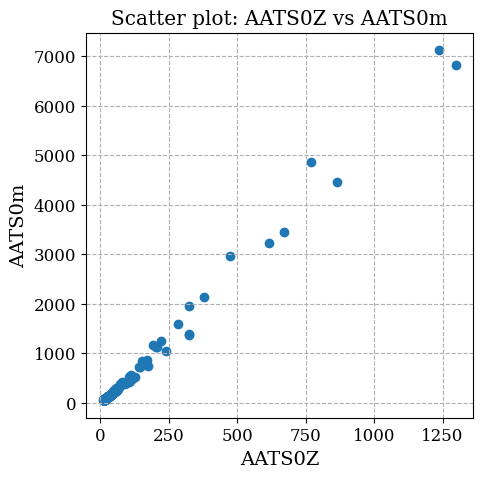

In [9]:
# TO BE COMPLETED

# remove the lines below if you do not need them and do not want to use them
most_corr_feat = sorted_corr.head(1).index[0] # here you can compute the most correlated feature

plt.scatter(df[feature_0], df[most_corr_feat])
plt.xlabel(feature_0)
plt.ylabel(most_corr_feat)
plt.title(f'Scatter plot: {feature_0} vs {most_corr_feat}')
plt.grid(True)
plt.show()


### Exercise 1.6
Take the feature least correlated with feature number 0, and draw a scatter plot with values of feature number 0 in the x-axis, and values of the least correlated feature in the y-axis.

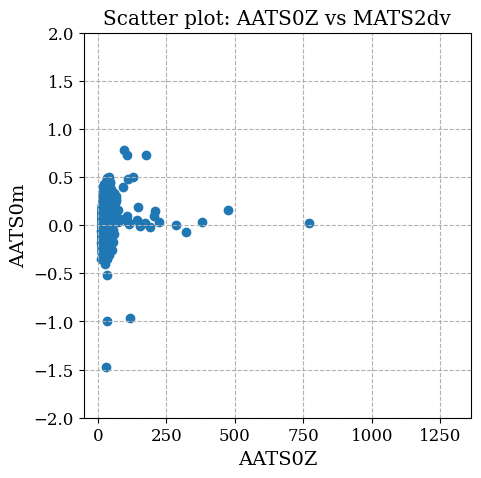

In [10]:
# TO BE COMPLETED

# remove the lines below if you do not need them or do not want to use them
least_corr_feat = sorted_corr.tail(1).index[0]
plt.scatter(df[feature_0], df[least_corr_feat])
plt.xlabel(feature_0)
plt.ylabel(most_corr_feat)
plt.title(f'Scatter plot: {feature_0} vs {least_corr_feat}')
plt.grid(True)

# suggestion: limit the y-axis with the command below if you do not want to see the ficticious values -99999
plt.ylim((-2,2))
plt.show()

### Exercise 1.7:
Draw the heat map of the absolute value of the correlation matrix. You should obtain a figure like this one:

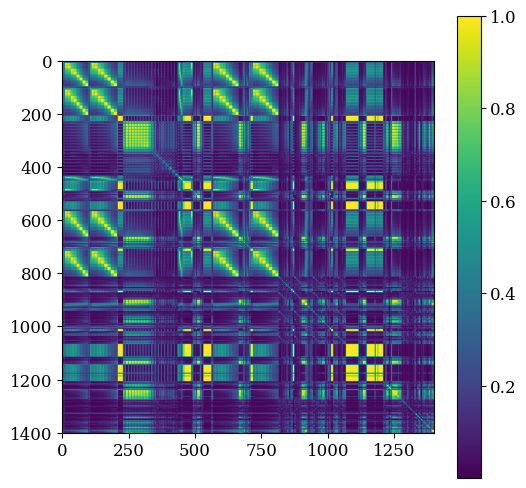


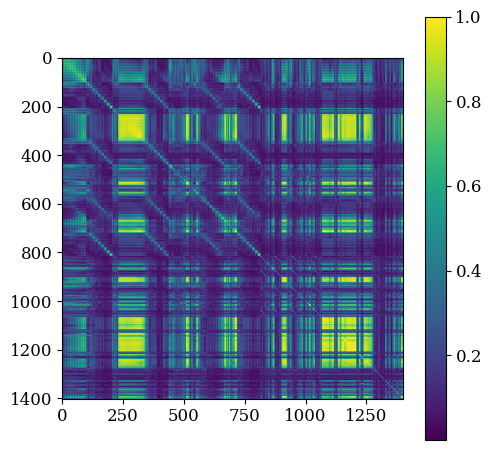

In [11]:
# TO BE COMPLETED

# Hint: you can complete the command lines below to draw the heatmap

plt.figure(figsize=(5.5,5.5))
im = plt.imshow(corr_df) # plt.imshow(PUT HERE YOUR ABSOLUTE VALUE CORRELATION MATRIX)
cbar = plt.colorbar(im)


### Exercise 1.8

From the correlation matrix, compute the distance matrix where each element is defined as $1-|correlation|$. Suggestion: print the distance matrix to see that it is as you expect.

In [12]:
# TO BE COMPLETED
distance_matrix = 1 - corr_df
distance_matrix

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,piPC3,piPC4,piPC5,piPC6,piPC7,piPC8,piPC9,qed,rotors,sbonds
AATS0Z,0.000000,0.214948,0.359037,0.176688,0.744794,0.000105,0.408717,0.176158,0.398551,0.215085,...,0.632909,0.616197,0.616177,0.633625,0.659291,0.687273,0.702827,0.968218,0.779833,0.868968
AATS0are,0.214948,0.000000,0.402358,0.062414,0.926148,0.218168,0.856186,0.009390,0.124876,0.010044,...,0.662281,0.671647,0.683479,0.688530,0.709256,0.735845,0.747449,0.845266,0.941667,0.931247
AATS0d,0.359037,0.402358,0.000000,0.270095,0.511492,0.358010,0.419457,0.384182,0.572138,0.441924,...,0.155068,0.140670,0.147006,0.143262,0.169880,0.205024,0.229258,0.872035,0.751191,0.792077
AATS0dv,0.176688,0.062414,0.270095,0.000000,0.796803,0.178382,0.620039,0.059407,0.213659,0.096665,...,0.537652,0.526539,0.523651,0.537304,0.561292,0.597781,0.617396,0.993302,0.822811,0.942832
AATS0i,0.744794,0.926148,0.511492,0.796803,0.000000,0.741513,0.195406,0.978451,0.822922,0.894832,...,0.524113,0.477344,0.442297,0.463473,0.474999,0.503245,0.519447,0.633357,0.646419,0.733341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
piPC8,0.687273,0.735845,0.205024,0.597781,0.503245,0.685067,0.557597,0.721724,0.878873,0.773675,...,0.047286,0.044877,0.043806,0.035201,0.016898,0.000000,0.021110,0.921446,0.897771,0.586552
piPC9,0.702827,0.747449,0.229258,0.617396,0.519447,0.700647,0.583222,0.733439,0.884198,0.781872,...,0.064758,0.068278,0.068913,0.061095,0.041776,0.021110,0.000000,0.940942,0.871869,0.564733
qed,0.968218,0.845266,0.872035,0.993302,0.633357,0.965258,0.605329,0.863429,0.811436,0.814351,...,0.982559,0.924708,0.887360,0.912001,0.913971,0.921446,0.940942,0.000000,0.644850,0.601049
rotors,0.779833,0.941667,0.751191,0.822811,0.646419,0.779299,0.591512,0.914762,0.994919,0.959240,...,0.894652,0.955379,0.975769,0.980727,0.939925,0.897771,0.871869,0.644850,0.000000,0.434993


The following cell shows you how to creat 10 clusters starting from the distance matrix. Read the code lines and make sure they are clear to you.

In [13]:
from sklearn.cluster import AgglomerativeClustering

# my_clustering = AgglomerativeClustering(n_clusters=10, linkage = 'single', affinity='precomputed') # if sklearn version<1.2
my_clustering = AgglomerativeClustering(n_clusters=10, linkage = 'single', metric='precomputed') #if sklearn version>=1.2
my_clustering = my_clustering.fit(distance_matrix)

print(my_clustering.labels_) # my_clustering.labels_ returns the number of the cluster each sample belongs to. 
set(my_clustering.labels_) # If you have 10 clusters, it should be a set of indexes from 0 to 9

[0 0 0 ... 0 0 0]


{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

In [14]:
for i in range(len(my_clustering.labels_)):
    print(f"is in cluster {my_clustering.labels_[i]}")


is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cluster 0
is in cl

For each cluster, we select a feature. It can be randonly selected, or it can be selected by a domain expert, or as you like. 

The function *select_features* defined in the following cell selects the first feature from each cluster (even if it can be implemented in a more efficient way). The function takes as inputs:
- my_clustering: output of AgglomerativeClustering
- features_list: list with all features


The function returns a list with the selected features. Note that the number of selected features is implicitely specify in the output of agglomerative clustering *my_clustering*. In the rest of the assignment you can use the function *select_features* or implement your own function to select a feature from each cluster.

In [15]:
# List of all features
features_list = df.drop(columns = ['Taste']).columns.to_list()

def select_features(my_clustering, features_list):

    selected_features = [] # it will be a list with names of the selected features. If you have 10 clusters, it will be a list with ten features

    index_features = np.arange(len(features_list))  # array from 0 to (number of features-1)
    
        
    for ind_l in set(my_clustering.labels_): # cycle from 0 to number of clusters

        mask = my_clustering.labels_ == ind_l # create mask to consider cluster ind_l  
        
        feat_list = [features_list[i] for i in list(index_features[mask])] # select all features belonging to cluster ind_l
        
        selected_features.append(feat_list[0]) # select only the first feature of the cluster
        
        # if True:
        #     print(f"Cluster {ind_l}")
        #     print(f"Selected feature: {feat_list[0]}")
        
    return selected_features
    
selected_features = select_features(my_clustering, features_list)

print('\n Final results. Selected features:')
print(selected_features)


 Final results. Selected features:
['AATS0Z', 'SRW03', 'PetitjeanIndex', 'nBondsT', 'MAXdCH2', 'fr_aldehyde', 'fr_piperzine', 'fr_lactone', 'EState_VSA5', 'n11FARing']


### Exercise 1.9: Using the functions above, cluster your features in 15 clusters and select one feature per cluster

In [16]:
# TO BE COMPLETED

my_clustering = AgglomerativeClustering(n_clusters=15, linkage = 'single', metric='precomputed')
my_clustering = my_clustering.fit(distance_matrix)

print('If everything is correct, the print below should be a set with values between 0 and 14')
print(set(my_clustering.labels_)) 

selected_features = select_features(my_clustering, features_list)

print('\n Final results. Selected features:')
print(selected_features)

If everything is correct, the print below should be a set with values between 0 and 14
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14}

 Final results. Selected features:
['AATS0Z', 'SRW03', 'MDEN-11', 'nBondsT', 'MAXdCH2', 'n7ARing', 'fr_imide', 'fr_lactone', 'EState_VSA5', 'n11FARing', 'MAXdS', 'fr_aldehyde', 'PetitjeanIndex', 'fr_Ar_COO', 'fr_piperzine']


# Exercise 2: feature selection for classification 

You have now all the ingredients to implement the feature selection algorithm shown in the lesson. The following exercise will guide you.

## Exercise 2.1: binary classifier with all features

Randomly split the original dataframe to create a train dataset and a validation dataset. You can use 70% of data for training, and 30% for validation.

Using all features, learn a binary classifier which is able to predict the taste of the molecule (sweet/bitter) from its features. Assess the performance of your classifier.

Note: You are free to choose the classifier you like. But we expect an accuracy on the validation dataset of at least 80%.

In [17]:
# TO BE COMPLETED

from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Train - validation split
split = train_test_split(df, test_size=0.3, random_state=42)
train_df = split[0]
test_df = split[1]

x_train = train_df.drop(columns=['Taste'])
y_train = train_df['Taste']

x_val = test_df.drop(columns=['Taste'])
y_val = test_df['Taste']

# Train your classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_val)

# Assess performance
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.2%}")


Accuracy: 87.10%


### Exercise 2.2: training only with a subset of features

Create a function *train_model* which trains a binary classifier to predict the taste of the molecules using only a subset of features. 

The function takes as inputs:

- x_train: entire training set you created before. x_train contains only the inputs of the training samples
- y_train: entire training set you created before. y_train contains only the target output of the training samples
- x_val: entire validation set you created before. x_val contains only the inputs of the validation samples
- y_val: entire validation set you created before. y_val contains only the target output of the validation samples
- features: list of features you want to consider for your training. Example: features = ['AATS0Z', 'SRW03', 'MDEN-11', 'nBondsT', 'MAXdCH2', 'n7ARing', 'fr_imide', 'fr_lactone', 'EState_VSA5', 'n11FARing', 'MAXdS', 'fr_aldehyde', 'PetitjeanIndex', 'fr_Ar_COO', 'fr_piperzine']


The function returns:
- accuracy on validation dataset

Test if your function works propery, using first all features and then using only the first 5 features

In [18]:
# TO BE COMPLETED

def train_model(x_train, y_train, x_val, y_val, features):

    x_train_new = x_train[features]
    x_val_new = x_val[features]

    clf = RandomForestClassifier(random_state=42)
    clf.fit(x_train_new, y_train)
    y_pred = clf.predict(x_val_new)

    # Assess performance
    accuracy_val = accuracy_score(y_val, y_pred)
    
    return accuracy_val
  

features = features_list
accuracy_val_1 = train_model(x_train, y_train, x_val, y_val, features)
print(f"Score on validation with all features: {accuracy_val_1:.2%}")

features = features_list[0:5] # test performance using first 5 features  
accuracy_val_2 = train_model(x_train, y_train, x_val, y_val, features)
print(f"Score on validation with first 5 features: {accuracy_val_2:.2%}")

Score on validation with all features: 87.10%
Score on validation with first 5 features: 77.24%


### Exercise 2.3: feature selection using agglomerative clustering

Let us now define a function *feature_selector* which computes a subset of features with the agglomerative clustering algorithm seen in the lesson. The function takes as inputs:
- x_train: entire training set you created before. x_train contains only the inputs of the training samples
- y_train: entire training set you created before. y_train contains only the target output of the training samples
- x_val: entire validation set you created before. x_val contains only the inputs of the validation samples
- y_val: entire validation set you created before. y_val contains only the target output of the validation samples
- distance_matrix: distance matrix you creted in exercise 1, and used for clustering
- features_list: list of ALL features
- n_f: desidered number of features (namely, number of clusters you created)

The function returns:
- list with selected features 
- score in validation


Hint: try to use the functions *select_features* (defined at the end of exercise 1) to select the features staring from the results of agglomerative clustering and the function *train_model* (defined in exercise 2.2) to compute the score in validation using only the features you selected

In [22]:
# TO BE COMPLETED OR MODIFIED AS YOU LIKE
def feature_selector(x_train, y_train, x_val, y_val, distance_matrix, features_list, n_f):
    
    # Create your clustering with n_f clusters
    my_clustering = AgglomerativeClustering(n_clusters=n_f, linkage = 'single', metric='precomputed')
    my_clustering = my_clustering.fit(distance_matrix)
    
    # select features
    selected_features = select_features(my_clustering, features_list)   # Use function select_features() end of ex. 1
    
    # validation accuracy
    accuracy_val = train_model(x_train, y_train, x_val, y_val, selected_features)       # use function  train_model()  ex. 2.2
    
    return selected_features, accuracy_val

# Test results with 50 clusters
n_f = 50
selected_features, accuracy_val = feature_selector(x_train, y_train, x_val, y_val,  distance_matrix, features_list, n_f)
print(f"Selected features: {selected_features}")
print(f"Validation score: {accuracy_val}")

Selected features: ['AATS0Z', 'MDEN-13', 'AMID_X', 'ETA_dAlpha_A', 'nBridgehead', 'fr_imide', 'MAXddsN', 'VSA_EState9', 'MAXdsN', 'MAXdsCH', 'SlogP_VSA10', 'MAXsF', 'PetitjeanIndex', 'fr_priamide', 'fr_piperzine', 'MAXssssN', 'SRW03', 'fr_para_hydroxylation', 'MAXaasN', 'PEOE_VSA8', 'fr_ketone', 'MAXdCH2', 'fr_oxime', 'fr_imidazole', 'n7ARing', 'EState_VSA6', 'EState_VSA3', 'PEOE_VSA5', 'fr_Ar_COO', 'fr_piperdine', 'fr_Ndealkylation1', 'PEOE_VSA13', 'fr_lactone', 'MDEN-23', 'nBondsT', 'EState_VSA5', 'EState_VSA7', 'MDEN-11', 'fr_unbrch_alkane', 'MDEN-33', 'PEOE_VSA12', 'fr_aryl_methyl', 'n11FARing', 'BCUTc-1l', 'MAXdS', 'MDEN-22', 'PEOE_VSA4', 'GhoseFilter', 'fr_aldehyde', 'fr_Ndealkylation2']
Validation score: 0.8285280728376327


### Exercise 2.4

Consider a number of clusters varying from 1 to 200.

For each considered number of clusters, select the one feature (as you like) and compute the corresponding accuracy in the validation dataset. Plot number of selected features vs accuracy in validation. 

If everything is correct, using 100 features (or even less) you should achieve a validation accuracy similar to the one achieved using all the features.

Hint: Do not make useless efforst! Try to use the functions you created above.

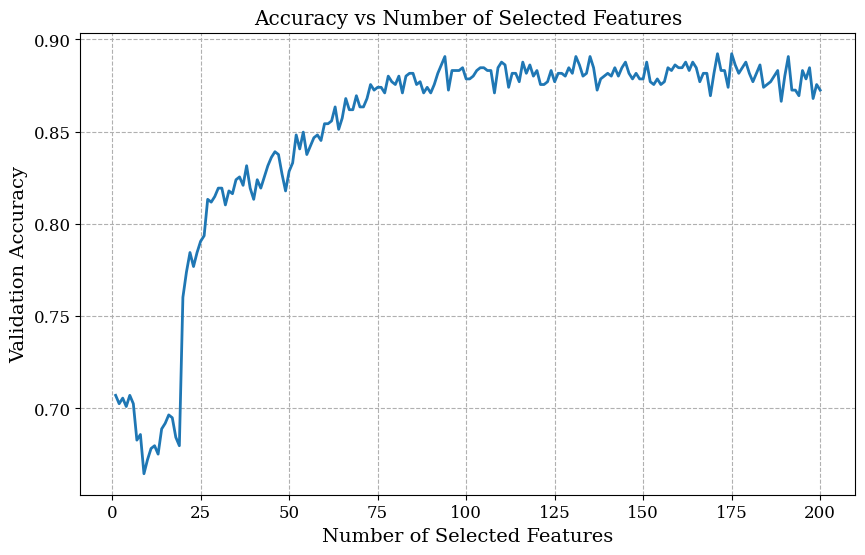

Best accuracy: 89.23% with 171 features


In [20]:
# TO BE COMPLETED

f_range = []
val_scores = []

for n_f in range(200): # varying number of features
    selected_features, accuracy_val = feature_selector(x_train, y_train, x_val, y_val, distance_matrix, features_list, n_f+1)
    f_range.append(n_f+1)
    val_scores.append(accuracy_val)

plt.figure(figsize=(10, 6))
plt.plot(f_range, val_scores)
plt.xlabel('Number of Selected Features')
plt.ylabel('Validation Accuracy')
plt.title('Accuracy vs Number of Selected Features')
plt.grid(True)
plt.show()

best_idx = np.argmax(val_scores)
best_n_features = f_range[best_idx]
best_score = val_scores[best_idx]

print(f"Best accuracy: {best_score:.2%} with {best_n_features} features")


## Instructions for ppt presentation

1. Describe the problem you want to solve
2. Describe how you solve the problem
3. Present and comment the results